---
# Part 10. 어텐션(Attention) 계산 — 오늘의 하이라이트

> **왜 배우나요?** 어텐션은 트랜스포머의 핵심. "각 단어가 문장 속 다른 단어들 중  
> 어디에 주목해야 하는지"를 계산하는 메커니즘으로, 내일 만들 인코더의 핵심 부품  
> 1:1 계산부터 시작해서 → 1:다 → 문장 전체로 차근차근 확장

## 검색엔진 비유로 이해하기

검색창에 "고양이 사료 추천"이라고 치면:

| 어텐션 용어 | 검색엔진 비유 | 역할 |
|---|---|---|
| **Query (Q)** | 내가 친 검색어 | "나는 이런 정보를 찾고 있어" |
| **Key (K)** | 각 문서의 제목/키워드 | "나는 이런 내용을 담고 있어" (간판) |
| **Value (V)** | 문서의 실제 내용 | 실제로 가져갈 정보 |

검색엔진은 ① 검색어(Q)와 모든 문서 제목(K)의 유사도를 계산하고 → ② 유사도가 높은 순으로 →  
③ 문서 내용(V)을 보여줌. 어텐션도 정확히 이 3단계

문장 안에서는 각 단어가 Query가 되어 "다른 단어들(Key) 중 나랑 관련 깊은 게 누구지?"를 계산하고,  
관련 깊은 단어의 정보(Value)를 많이 가져와 자신의 표현을 업데이트

## 10.1 [1:1 계산] 벡터 두 개는 얼마나 닮았나? — 내적

> 가장 작은 단위부터. 벡터 하나 vs 벡터 하나의 유사도 = 내적(dot product)  
> 내적 = 같은 위치의 숫자끼리 곱해서 전부 더한 것. 방향이 비슷한 벡터일수록 값이 커짐

### [질문] GloVe 임베딩 공간에서 `cat`은 `dog`와 `pizza` 중 누구와 내적이 클까?

### [실습]

In [5]:
import torch

corpus = [
    "the cat sat on the mat",
    "the dog sat on the rug",
    "a cat and a dog played",
]


In [6]:
# ① 모든 문장을 단어로 쪼개서 중복 없는 단어 집합 만들기
all_words = []

for sentence in corpus:
    all_words.extend(sentence.split())

unique_words = sorted(set(all_words))

print("어휘 사전에 들어갈 단어들: ", unique_words)


어휘 사전에 들어갈 단어들:  ['a', 'and', 'cat', 'dog', 'mat', 'on', 'played', 'rug', 'sat', 'the']


In [7]:
# ② 단어 → ID 사전(word_to_id) 만들기: {단어: 번호} 형태

word_to_id = {word: index for index, word in enumerate(unique_words)}

print("word to id: ", word_to_id)
print("어휘 사전 크기 (vocab size):", len(word_to_id))

word to id:  {'a': 0, 'and': 1, 'cat': 2, 'dog': 3, 'mat': 4, 'on': 5, 'played': 6, 'rug': 7, 'sat': 8, 'the': 9}
어휘 사전 크기 (vocab size): 10


In [8]:
# ③ 새 문장을 토큰 ID 시퀀스(Tensor)로 바꾸기

sentence = "the cat sat on the mat"
token_ids = torch.tensor([word_to_id[word] for word in sentence.split()])

print("문장:", sentence)
print("토큰 ID:", token_ids, "shape:", token_ids.shape)


문장: the cat sat on the mat
토큰 ID: tensor([9, 2, 8, 5, 9, 4]) shape: torch.Size([6])


In [9]:
import torch
import torch.nn as nn

torch.manual_seed(42)   # 결과 재현을 위한 랜덤 시드 고정

vocab_size = len(word_to_id)
embedding_dim = 50  # 벡터 하나의 길이 (의미의 차원수)

embedding_layer = nn.Embedding(vocab_size, embedding_dim)
print("임베딩 표(가중치) shape:", embedding_layer.weight.shape)

임베딩 표(가중치) shape: torch.Size([10, 50])


In [10]:
# 토큰 ID 시퀀스를 넣으면 → 각 ID의 행을 꺼내 벡터 시퀀스로

embedded_sentence = embedding_layer(token_ids)

print("입력 token ids shape:", token_ids.shape)
print("출력 임베딩 shape:", embedded_sentence.shape) 

입력 token ids shape: torch.Size([6])
출력 임베딩 shape: torch.Size([6, 50])


In [12]:
import numpy as np
import torch
import torch.nn as nn

# ① 우리 사전의 단어 순서(ID 순서)대로 GloVe 벡터를 쌓아 행렬 만들기
glove_matrix = np.stack([glove[word] for word in unique_words])

print("glove_matrix shape:", glove_matrix.shape)


glove_matrix shape: (10, 50)


In [13]:
# ② Embedding을 만들고, 그 가중치(weight)에 glove_matrix를 복사해 넣기

embedding_layer = nn.Embedding(vocab_size, embedding_dim)
embedding_layer.weight.data.copy_(torch.tensor(glove_matrix))
embedding_layer.weight.requires_grad = False


In [14]:
# ③ "the cat sat on the mat"의 token_ids를 통과시켜 shape 확인

embedded_sentence = embedding_layer(token_ids)
print("embedding sentence shape: ", embedded_sentence.shape)

print("\n 'cat' 위치(1번째 토큰)의 임베딩과 glove['cat']이 같은지:" , 
      torch.allclose(embedded_sentence[1], torch.tensor(glove["cat"])))


embedding sentence shape:  torch.Size([6, 50])

 'cat' 위치(1번째 토큰)의 임베딩과 glove['cat']이 같은지: True


In [15]:
import math
import torch


def create_positional_encoding(max_len, embedding_dim):
    """위치마다 고유한 sin/cos 패턴 벡터를 만들어 (max_len, embedding_dim) 행렬로 반환"""
    position = torch.arange(max_len).unsqueeze(1).float()              # (max_len, 1) 위치 번호 0,1,2,...
    div_term = torch.exp(torch.arange(0, embedding_dim, 2).float()
                         * (-math.log(10000.0) / embedding_dim))       # 주파수를 다양하게
    positional_encoding = torch.zeros(max_len, embedding_dim)
    positional_encoding[:, 0::2] = torch.sin(position * div_term)      # 짝수 채널: sin
    positional_encoding[:, 1::2] = torch.cos(position * div_term)      # 홀수 채널: cos
    return positional_encoding


positional_encoding = create_positional_encoding(max_len=100, embedding_dim=50)
print("positional_encoding shape:", positional_encoding.shape, " ← (max_len, embedding_dim)")

positional_encoding shape: torch.Size([100, 50])  ← (max_len, embedding_dim)


In [22]:
# 사용법은 이게 전부: 문장 길이만큼 잘라서 임베딩에 "더하기"
sequence_length = embedded_sentence.shape[0]     # 6

position_aware_sentence = embedded_sentence + positional_encoding[:sequence_length]
print("임베딩            :", embedded_sentence.shape)
print("위치 도장 (잘라서) :", positional_encoding[:sequence_length].shape)
print("더한 결과          :", position_aware_sentence.shape, " ← shape은 그대로이고 정보만 추가됨")

임베딩            : torch.Size([6, 50])
위치 도장 (잘라서) : torch.Size([6, 50])
더한 결과          : torch.Size([6, 50])  ← shape은 그대로이고 정보만 추가됨


In [17]:
# 사전학습 단어 벡터 로드 (최초 1회만 다운로드(~66MB), 이후엔 캐시에서 바로 로드)
import gensim.downloader as gensim_api

glove = gensim_api.load("glove-wiki-gigaword-50")

In [18]:
import torch

cat_vector = torch.tensor(glove["cat"])
dog_vector = torch.tensor(glove["dog"])
pizza_vector = torch.tensor(glove["pizza"])

print("벡터 shape:", cat_vector.shape, " ← 50차원 벡터")


벡터 shape: torch.Size([50])  ← 50차원 벡터


In [19]:
# 내적을 계산해 보세요. cat은 dog, pizza 중 누구와 더 비슷할까요?

cat_dog_score = torch.dot(cat_vector, dog_vector)
cat_pizza_score = torch.dot(cat_vector, pizza_vector)

print(" cat, dog sim : ", cat_dog_score.item())
print(" cat, pizza sim : ", cat_pizza_score.item())



 cat, dog sim :  19.73906898498535
 cat, pizza sim :  9.426480293273926


## 10.2 [1:다 계산] 그런데 단어는 여러 개인데요?

방금 내적으로 1:1 유사도가 나옴

### [질문] 그럼 Query 1개(`cat`)와 문장 속 토큰 6개 전부의 유사도를 한 번에 구하려면?

방법 1: `torch.dot`을 6번 반복(for문)... 되긴 하는데, 토큰이 1000개면?

방법 2: 행렬곱(matmul, `@`). 필요한 규칙은 딱 하나  

$(n, {\bf k}) \; @ \; ({\bf k}, m) \;\to\; (n, m)$ — 안쪽 두 숫자(k)가 같아야 하고, 결과는 바깥 두 숫자

행렬곱의 정체가 바로 "행 벡터와 열 벡터의 내적을 전부 한꺼번에". 먼저 규칙만 30초 확인

In [20]:
# 행렬곱 shape 규칙 확인
import torch

print("(2,3) @ (3,5) = ", (torch.rand(2, 3) @ torch.rand(3,5)).shape)


(2,3) @ (3,5) =  torch.Size([2, 5])


In [ ]:
# 안쪽 숫자가 다르면?



이제 문제에 적용:
- Query 벡터: `(50,)` — "cat"의 벡터
- Key 행렬(토큰 6개의 벡터를 쌓은 것): `(6, 50)`
- `Key행렬 @ Query벡터` → `(6, 50) @ (50,) → (6,)` — 내적 6번을 행렬곱 한 번으로 처리

### [실습] "하나씩 → 한 번에" 계산

In [24]:
# sentence = "the cat sat on the mat" (위치 정보까지 더한 버전)을 사용합니다.
sentence_vectors = position_aware_sentence
sentence_words = ["the", "cat", "sat", "on", "the", "mat"]

query_vector = sentence_vectors[1]  # "cat"을 query로

print("query vector shape", query_vector.shape)
print("key vector shape", sentence_vectors.shape)




query vector shape torch.Size([50])
key vector shape torch.Size([6, 50])


In [28]:
# 행렬곱으로 "cat" Query와 6개 토큰 전체의 유사도를 한 번에 계산

similarity_score = sentence_vectors @ query_vector

print(similarity_score)

tensor([28.5815, 44.8952, 29.9222, 27.4563, 24.7616, 26.8276])


In [31]:
# 자기 자신("cat" 위치)과의 유사도가 가장 크게 나오는 것을 확인하세요

for word, score in zip(sentence_words, similarity_score):
    print(f" (query) cat --> (key)  {word}: {score.item()}")


 (query) cat --> (key)  the: 28.58151626586914
 (query) cat --> (key)  cat: 44.89523696899414
 (query) cat --> (key)  sat: 29.92218589782715
 (query) cat --> (key)  on: 27.456323623657227
 (query) cat --> (key)  the: 24.761579513549805
 (query) cat --> (key)  mat: 26.827564239501953


## 10.3 Softmax — 점수를 가중치로 바꾸기

### [질문] 위에서 구한 유사도 점수(예: 31.2, 18.5, ...)를 그대로 가중치로 쓰면 안 될까?

문제가 두 가지 있음:
1. 스케일이 제멋대로: 점수 합이 100이 될 수도, 3이 될 수도 있어서 "얼마나 가져올지" 비율로 쓸 수 없음
2. 음수도 나옴: "-5만큼 주목한다"는 게 무슨 뜻인지 애매함

**해결책: `softmax`** — 점수들을 전부 0~1 사이, 합이 정확히 1인 확률처럼 변환  
- 큰 점수 → 큰 몫, 작은 점수 → 작은 몫 (순위는 유지)
- 지수함수를 쓰기 때문에 가장 큰 점수에 몫이 확 쏠리는 특징 (soft한 max라서 softmax)

**`dim` 개념 먼저 확인.** softmax에는 어느 방향으로 정규화할지를 `dim`으로 알려줘야 함  
성적표(3명 학생 × 4과목)로 감을 잡아보기

In [33]:
# dim = "어느 방향으로 접을 것인가" 
import torch

grade_matrix = torch.tensor([[90., 80., 70., 60.],     # 학생0 의 국/영/수/과
                             [85., 95., 75., 65.],     # 학생1
                             [70., 60., 90., 100.]])   # 학생2


In [34]:
print("성적표 shape:", grade_matrix.shape, " ← (학생 수, 과목 수)")

성적표 shape: torch.Size([3, 4])  ← (학생 수, 과목 수)


In [36]:
print("과목별 평균 mean:", grade_matrix.mean(dim=0), " ← 학생 방향으로 접음, 결과 4개")

과목별 평균 mean: tensor([81.6667, 78.3333, 78.3333, 75.0000])  ← 학생 방향으로 접음, 결과 4개


In [37]:
print("학생별 평균 mean:", grade_matrix.mean(dim=1), " ← 과목 방향으로 접음, 결과 3개")

학생별 평균 mean: tensor([75., 80., 80.])  ← 과목 방향으로 접음, 결과 3개


In [38]:
print("마지막 차원 평균 :", grade_matrix.mean(dim=-1))
    

마지막 차원 평균 : tensor([75., 80., 80.])


### [실습] softmax 직접 확인


In [39]:
import torch

# 점수 3개짜리 간단한 예시
raw_scores = torch.tensor([3.0, 1.0, 0.5])


In [41]:
# softmax를 적용해 보세요. (벡터가 1차원이므로 dim은 마지막 차원)

attention_weights = torch.softmax(raw_scores, dim=-1)

print("sofmax 전: ", raw_scores, " 합 =", raw_scores.sum().item())
print("sofmax 후: ", attention_weights, " 합 =", attention_weights.sum().item())


sofmax 전:  tensor([3.0000, 1.0000, 0.5000])  합 = 4.5
sofmax 후:  tensor([0.8214, 0.1112, 0.0674])  합 = 1.0


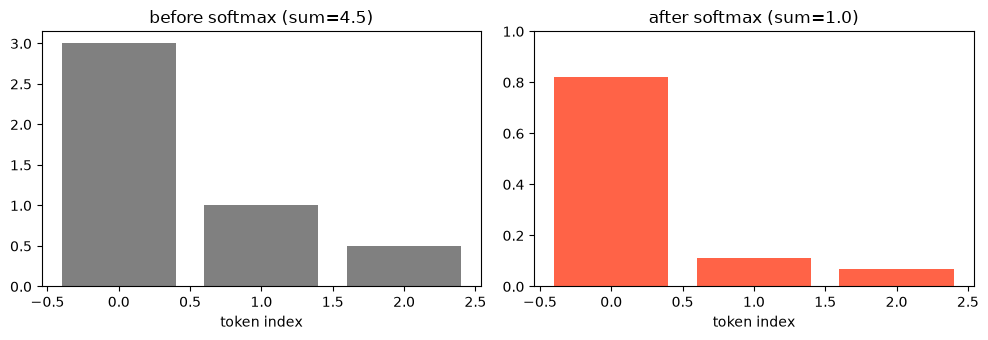

→ 점수 차이(3.0 vs 1.0)보다 가중치 차이(0.82 vs 0.11)가 훨씬 극적으로 벌어졌죠?
  softmax는 '승자에게 몰아주되, 나머지도 조금은 남겨 주는' 부드러운 선택입니다.


In [42]:
# 정규화 전/후를 막대그래프로 비교 — "가장 유사한 곳에 가중치가 쏠린다"를 눈으로 확인
import matplotlib.pyplot as plt

figure, (left_axis, right_axis) = plt.subplots(1, 2, figsize=(10, 3.5))

left_axis.bar(range(3), raw_scores.numpy(), color="gray")
left_axis.set_title(f"before softmax (sum={raw_scores.sum().item():.1f})")
left_axis.set_xlabel("token index")

right_axis.bar(range(3), attention_weights.numpy(), color="tomato")
right_axis.set_title(f"after softmax (sum={attention_weights.sum().item():.1f})")
right_axis.set_ylim(0, 1)
right_axis.set_xlabel("token index")

plt.tight_layout()
plt.show()
print("→ 점수 차이(3.0 vs 1.0)보다 가중치 차이(0.82 vs 0.11)가 훨씬 극적으로 벌어졌죠?")
print("  softmax는 '승자에게 몰아주되, 나머지도 조금은 남겨 주는' 부드러운 선택입니다.")

# raw_scores를 [3.0, 3.0, 3.0]으로 바꾸면? [30, 10, 5]로 바꾸면? 그래프로 확인해 보세요

## 10.4 Scaled Dot-Product Attention — 조각을 모아 완성

이제 어텐션을 조립. 논문 "Attention Is All You Need"의 핵심 수식은 코드로 4줄

| 단계 | 코드 | 뜻 |
|---|---|---|
| ① 유사도 계산 | `scores = Q @ K.T` | 모든 Query × 모든 Key 내적을 행렬곱 한 번에 |
| ② 스케일링 | `scores / sqrt(d_k)` | 차원이 크면 내적 값이 너무 커져 softmax가 극단적으로 쏠림 → 완화 |
| ③ 가중치화 | `softmax(scores, dim=-1)` | 각 Query 행마다 합=1인 가중치로 변환 |
| ④ 정보 수집 | `weights @ V` | 가중치만큼 Value를 섞어서 가져오기 (가중평균) |

**shape 흐름 (seq_len=6, d_k=50 기준):**

In [44]:
import math
import torch

# 일단 q, k, v 모두 같은 문장 벡터 사용
query_matrix = sentence_vectors  # (6, 50) 
key_matrix = sentence_vectors  # (6, 50) 
value_matrix = sentence_vectors  # (6, 50) 

In [47]:
# ① 유사도: 모든 Query와 모든 Key의 내적을 행렬곱 한 번으로

attention_scores = query_matrix @ key_matrix.T

print(query_matrix.shape, key_matrix.shape, key_matrix.T.shape)
print("attention_scores", attention_scores.shape)


torch.Size([6, 50]) torch.Size([6, 50]) torch.Size([50, 6])
attention_scores torch.Size([6, 6])


In [49]:
# ② 스케일링: 벡터 차원 d_k의 제곱근으로 나누기

d_k = key_matrix.shape[-1]
scaled_scores = attention_scores / math.sqrt(d_k) 

print("scaled score shape:", scaled_scores.shape)



scaled score shape: torch.Size([6, 6])


In [51]:
# ③ softmax: 각 Query "행"마다 합=1이 되어야 합니다. dim은 뭘까요?
#    (각 행 안에서, 마지막 차원 방향으로 정규화)

attention_weights = torch.softmax(scaled_scores, dim=-1)
print("weight shape: ", attention_weights.shape)
print("0번쨰 행의 합:", attention_weights[0].sum().item())



weight shape:  torch.Size([6, 6])
0번쨰 행의 합: 0.9999998807907104


In [52]:
# ④ 정보 수집: 가중치로 Value들을 섞기

attention_output = attention_weights @ value_matrix
print("output shape:", attention_output.shape)  # (6, 50)

output shape: torch.Size([6, 50])


> 📌 **정리:** ① 행렬곱(1:1 내적 → 다:다 유사도를 전부 한 번에) → ② 스칼라 나눗셈 →  
> ③ softmax(dim=-1, 행마다 합 1) → ④ 행렬곱(가중평균). 전부 오늘 다룬 연산들의 조합  
> 입력과 출력의 shape이 같다는 점도 중요 (그래서 층층이 쌓을 수 있음)

In [ ]:
# 어텐션 가중치 (6,6) 행렬을 히트맵으로 — "누가 누구를 쳐다보는가"
import matplotlib.pyplot as plt

plt.figure(figsize=(5.5, 4.5))
plt.imshow(attention_weights.detach().numpy(), cmap="viridis")
plt.xticks(range(6), sentence_words)
plt.yticks(range(6), sentence_words)
plt.xlabel("Key")  # (주목 받는 토큰)
plt.ylabel("Query")  # (주목 하는 토큰)
plt.title("Attention Weights")
plt.colorbar()
plt.show()
print("각 행이 밝을수록 그 토큰에 많이 주목한다는 뜻. 대각선(자기 자신)이 밝게 나타나는지 확인")

### [실습] 함수로 묶기 — 내일 재사용할 핵심 부품

방금 만든 4단계를 함수 하나로 포장. 내일 멀티헤드 어텐션에서 이 함수를 그대로 재사용  
(방금 셀에서 실행한 4줄을 `def` 안에 옮기는 것)

In [ ]:
import math
import torch

# 어텐션 함수 작성

In [ ]:
# 테스트



---
# Part 11. 앞이랑 연결하기 — Self-Attention

### [질문] 방금은 Q = K = V = 문장 벡터를 그대로 사용. 뭔가 아쉬운 점이 없었나?

히트맵을 다시 보면 — 사실상 비슷한 단어끼리 세게 주목만 하고 있음 (the↔the처럼)  
하지만 실제 언어에서는 "주어→동사", "대명사→그것이 가리키는 명사"처럼 다양한 종류의 관계에 주목해야 함

**해결책:** 같은 문장 벡터에서 출발하되, 서로 다른 세 개의 변환을 거쳐  
Query용, Key용, Value용 벡터를 따로 생성. 이 변환들은 학습을 통해  
"어떤 관계에 주목할지"를 스스로 익히게 됨

**변환의 정체 = Linear Layer.** 내부에 행렬 하나를 들고 있다가 입력에 곱해서  
벡터를 다른 벡터로 바꿔주는, 딥러닝의 가장 기본 부품

In [ ]:
import torch
import torch.nn as nn




> **Self-Attention의 "Self"란:** Q, K, V가 모두 같은 입력 문장에서 나온다는 뜻  
> (번역기의 디코더처럼 Q는 영어 문장에서, K/V는 한국어 문장에서 오면 "Cross"-Attention)

### [실습] 임베딩 → 변환 3개 → 어텐션 = Self-Attention

In [ ]:
import torch
import torch.nn as nn

torch.manual_seed(42)
embedding_dim = 50

# Q, K, V를 만드는 세 개의 서로 다른 "안경" (Linear 변환)]



In [ ]:
# ① 같은 입력(sentence_vectors)에 서로 다른 안경을 씌워 Q, K, V 만들기



In [ ]:
# ② 아까 만든 함수에 넣어 self-attention 완성



In [ ]:
# 학습 전이라 가중치 자체에 의미는 아직 없지만, 구조는 실제 트랜스포머와 동일
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))
plt.imshow(self_attention_weights.detach().numpy(), cmap="viridis")
plt.xticks(range(6), sentence_words)
plt.yticks(range(6), sentence_words)
plt.title("Self-Attention Weights (Linear 변환 적용 후)")
plt.colorbar()
plt.show()

### [실습] Day 1 종합 미니 실습 — 새 문장으로 처음부터 끝까지

오늘 배운 전체 파이프라인을 새로운 문장으로 직접 구현

```
문장 → ① 토큰화 → ② 임베딩(GloVe) → ③ 위치 인코딩 더하기 → ④ Q/K/V 만들기 → ⑤ Self-Attention
```

새 문장: `"the dog sat on the rug"` (모든 단어가 사전에 포함되어 있음)

In [ ]:
import torch

new_sentence = "the dog sat on the rug"

# ① 토큰화: word_to_id를 사용해 토큰 ID Tensor로


print("① token_ids:", new_token_ids, new_token_ids.shape)          # 예상: (6,)

In [ ]:
# ② 임베딩: 아까 만든 embedding_layer (GloVe 이식 완료본) 통과


print("② embedded:", new_embedded.shape)                           # 예상: (6, 50)


In [ ]:
# ③ 위치 인코딩: positional_encoding에서 문장 길이만큼 잘라 더하기


print("③ position_aware:", new_position_aware.shape)               # 예상: (6, 50)


In [ ]:
# ④ Q, K, V: 위에서 만든 query_projection / key_projection / value_projection 사용



print("④ Q/K/V:", new_query.shape, new_key.shape, new_value.shape)


In [ ]:
# ⑤ Self-Attention 실행 (만들어둔 함수 사용)


print("⑤ output:", final_output.shape, " weights:", final_weights.shape)   # (6,50), (6,6)

---
# Day 1 마무리

오늘 다룬 내용:

| 파트 | 부품 | 사용한 PyTorch 기술 |
|---|---|---|
| 오전 | 텐서 기초 | `tensor/zeros/ones/rand/arange`, `shape/dtype/device`, `.to(device)` |
| 오후 | 토큰화 | `torch.tensor` — 문장 → `(seq_len,)` |
| 오후 | 임베딩 (GloVe) | `nn.Embedding`, `weight.data.copy_` |
| 오후 | 어텐션 (1:1 → 1:다 → 다:다) | `torch.dot` → 행렬곱 → `softmax(dim=-1)` |
| 오후 | **Self-Attention** | `nn.Linear` 변환 3개 + 위의 전부 |

어텐션의 정체가 결국 내적 → 행렬곱 → softmax의 조합이라는 것을 직접 구현해보며 확인

## 내일(Day 2) 예고

- **오전**: 어텐션을 여러 개(head) 동시에 → Multi-Head Attention (`chunk`, `view` 활용)
- **오후**: FeedForward · LayerNorm · Residual → 인코더 1-layer → layer 쌓아 인코더 완성